# Laboratorio 6 — Reconstrucción LAB1: Regresión Lineal Simple con Red Neuronal

Reconstrucción del **LAB1** (regresión lineal simple sobre el dataset "barba del mago") usando
**PyTorch**, tal como pide el `statemant.md` del LAB6. Se utilizan:

- objeto **Dataset** y **DataLoader** para el manejo de datos,
- objeto **de costo** (`nn.MSELoss`) y **de optimización** (`optim.Adam`),
- objeto **para guardar los pesos** (`torch.save` / `state_dict`),
- **generación de métricas** (MSE, RMSE, MAE y $R^2$) sobre la partición 80/20.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from matplotlib import pyplot

torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cpu


/home/zahir/IA1/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 1. Dataset "barba del mago" (LAB1 original)

Los mismos 100 puntos usados en `main.py`/`main_rand.py`: `x` es el tamaño de la barba (cm) y `y`
el daño mágico inferido.

In [2]:
x = [
    54, 58, 41, 92, 32, 27, 33, 15, 53, 98,
    35, 78, 32, 17, 24, 55, 29, 85, 35, 45,
    28, 59, 37, 51, 28, 53, 30, 25, 36, 21,
    64, 52, 86, 39, 21, 20, 97, 24, 70, 25,
    40, 38, 33, 28, 33, 46, 74, 56, 58, 26,
    25, 75, 18, 72, 35, 42, 42, 67, 44, 22,
    54, 26, 71, 27, 25, 79, 47, 29, 43, 25,
    42, 16, 24, 49, 31, 25, 17, 28, 30, 43,
    66, 41, 84, 22, 74, 55, 84, 14, 65, 45,
    52, 32, 89, 44, 90, 88, 77, 20, 53, 28,
]

y = [
    289, 408, 198, 451, 102, 348, 240, 429, 155, 485,
    115, 439, 321, 222, 378, 278, 181, 418, 472, 230,
    130, 355, 258, 412, 310, 201, 448, 162, 390,  95,
    332, 284, 435, 225, 366, 141, 480, 251, 403, 208,
    318, 175, 465, 263, 375, 122, 422, 301, 219, 344,
    148, 442, 275, 392, 187, 468, 239, 351, 110, 416,
    312, 212, 458, 169, 382, 269, 433, 134, 330, 292,
    192, 477, 245, 401, 143, 427, 306, 221, 360, 108,
    339, 253, 460, 167, 397, 287, 444, 128, 323, 233,
    371, 199, 491, 156, 407, 261, 347,  92, 420, 309,
]

X = torch.tensor(x, dtype=torch.float32).view(-1, 1)
Y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

print(f"Ejemplos m = {X.shape[0]}, caracteristicas n = {X.shape[1]}")

# Normalización de la característica y del objetivo (media y desviación estándar)
mu = X.mean()
sigma = X.std()
mu_y = Y.mean()
sigma_y = Y.std()

X_norm = (X - mu) / sigma
Y_norm = (Y - mu_y) / sigma_y
print(f"Media X = {mu:.3f}, Desviacion estandar X = {sigma:.3f}")
print(f"Media Y = {mu_y:.3f}, Desviacion estandar Y = {sigma_y:.3f}")

Ejemplos m = 100, caracteristicas n = 1
Media X = 45.320, Desviacion estandar X = 22.132
Media Y = 300.320, Desviacion estandar Y = 114.876


## 2. Objeto Dataset

La clase `BarbaDataset` hereda de `torch.utils.data.Dataset` y define `__len__` y `__getitem__`.

In [3]:
class BarbaDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.Y[index]

## 3. Partición 80% / 20% y DataLoader

Siguiendo el criterio de los laboratorios anteriores, el 80% de los ejemplos se usa para
entrenamiento y el 20% para prueba (datos nunca vistos en el entrenamiento).

In [4]:
dataset = BarbaDataset(X_norm, Y_norm)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_set, test_set = torch.utils.data.random_split(dataset, [train_size, test_size])
print(f"Entrenamiento: {len(train_set)} | Prueba: {len(test_set)}")

Entrenamiento: 80 | Prueba: 20


In [5]:
batch_size = 16
train_loader = DataLoader(dataset=train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_set, batch_size=batch_size, shuffle=True)

## 4. Modelo (red neuronal = regresión lineal simple)

Una única capa lineal `nn.Linear(1, 1)` equivale a la hipótesis $h(x) = \theta_0 + \theta_1 x$.

In [6]:
class RedRegresion(nn.Module):
    def __init__(self):
        super(RedRegresion, self).__init__()
        self.fc = nn.Linear(1, 1)

    def forward(self, x):
        return self.fc(x)

model = RedRegresion().to(device)

## 5. Objetos de costo y optimización

In [7]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
print(criterion, optimizer)

## 6. Entrenamiento

Se registra el costo J por época para graficar la convergencia.

In [8]:
num_epochs = 2000
log_each = 200
J_history = []

model.train()
for epoch in range(1, num_epochs + 1):
    epoch_loss = []

    for x_b, y_b in train_loader:
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        pred = model(x_b)
        loss = criterion(pred, y_b)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss.append(loss.item())

    J_history.append(sum(epoch_loss) / len(epoch_loss))

    if not epoch % log_each:
        print(f"Epoca {epoch}/{num_epochs} Costo J = {J_history[-1]:.4f}")

Epoca 200/2000 Costo J = 0.7612
Epoca 400/2000 Costo J = 0.7615
Epoca 600/2000 Costo J = 0.7614
Epoca 800/2000 Costo J = 0.7626
Epoca 1000/2000 Costo J = 0.7616
Epoca 1200/2000 Costo J = 0.7619
Epoca 1400/2000 Costo J = 0.7617
Epoca 1600/2000 Costo J = 0.7618
Epoca 1800/2000 Costo J = 0.7614
Epoca 2000/2000 Costo J = 0.7615


## 7. Gráfico de costo

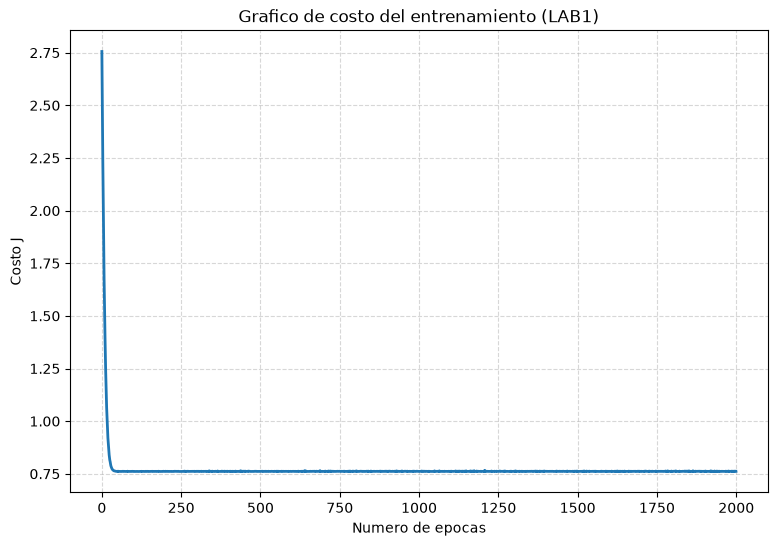

In [9]:
pyplot.figure(figsize=(9, 6))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de epocas')
pyplot.ylabel('Costo J')
pyplot.title('Grafico de costo del entrenamiento (LAB1)')
pyplot.grid(True, linestyle='--', alpha=0.5)
pyplot.savefig('costo.png')
pyplot.show()

## 8. Métricas y ajuste del modelo

In [10]:
def metricas_regresion(loader, model, nombre):
    model.eval()

    y_true, y_pred = [], []
    with torch.no_grad():
        for x_b, y_b in loader:
            pred = model(x_b.to(device)).cpu()
            # devolver las predicciones y objetivos a la escala original
            y_pred.extend((pred * sigma_y + mu_y).numpy().ravel())
            y_true.extend((y_b * sigma_y + mu_y).numpy().ravel())

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"[{nombre}] MSE = {mse:.2f} | RMSE = {rmse:.2f} | MAE = {mae:.2f} | R2 = {r2:.4f}")

    return y_true, y_pred

metricas_regresion(train_loader, model, "Entrenamiento")
metricas_regresion(test_loader, model, "Prueba")

[Entrenamiento] MSE = 10042.02 | RMSE = 100.21 | MAE = 83.11 | R2 = 0.2400
[Prueba] MSE = 10309.03 | RMSE = 101.53 | MAE = 82.15 | R2 = 0.1556


([np.float32(418.0),
  np.float32(323.0),
  np.float32(263.0),
  np.float32(355.0),
  np.float32(401.0),
  np.float32(309.0),
  np.float32(134.0),
  np.float32(472.0),
  np.float32(110.0),
  np.float32(222.0),
  np.float32(444.0),
  np.float32(162.0),
  np.float32(403.0),
  np.float32(382.0),
  np.float32(378.0),
  np.float32(442.0),
  np.float32(208.0),
  np.float32(219.0),
  np.float32(427.0),
  np.float32(225.0)],
 [np.float32(396.97516),
  np.float32(346.0917),
  np.float32(251.95735),
  np.float32(330.8267),
  np.float32(305.38495),
  np.float32(251.95735),
  np.float32(254.50153),
  np.float32(269.76657),
  np.float32(292.6641),
  np.float32(223.97147),
  np.float32(394.43097),
  np.float32(244.32483),
  np.float32(358.81256),
  np.float32(244.32483),
  np.float32(241.78067),
  np.float32(371.53345),
  np.float32(244.32483),
  np.float32(328.2825),
  np.float32(244.32483),
  np.float32(279.94324)])

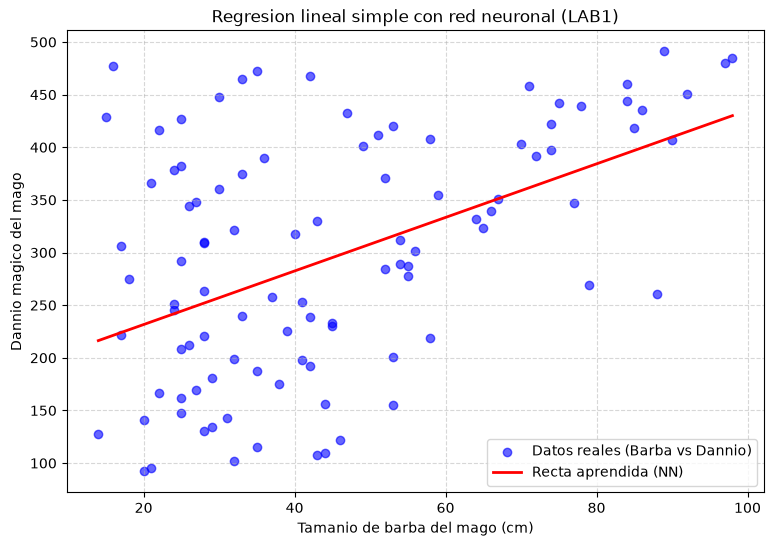

In [11]:
x_line = torch.linspace(X.min(), X.max(), 200).view(-1, 1)
x_line_norm = (x_line - mu) / sigma
y_line = (model(x_line_norm.to(device)).cpu().detach() * sigma_y + mu_y).numpy()

pyplot.figure(figsize=(9, 6))
pyplot.scatter(X.numpy(), Y.numpy(), color='blue', alpha=0.6,
               label='Datos reales (Barba vs Dannio)')
pyplot.plot(x_line.numpy(), y_line, color='red', linewidth=2, label='Recta aprendida (NN)')
pyplot.xlabel('Tamanio de barba del mago (cm)')
pyplot.ylabel('Dannio magico del mago')
pyplot.title('Regresion lineal simple con red neuronal (LAB1)')
pyplot.legend()
pyplot.grid(True, linestyle='--', alpha=0.5)
pyplot.savefig('ajuste.png')
pyplot.show()

## 9. Guardar los pesos del modelo

In [12]:
PATH = './checkpoint.pt'
torch.save(model.state_dict(), PATH)
print("Pesos guardados en:", PATH)

Pesos guardados en: ./checkpoint.pt


## 10. Cargar el modelo y predecir

Equivalente a `main.py`: dada la barba de un mago, se infiere su daño con los pesos guardados.

In [13]:
model_loaded = RedRegresion().to(device)
model_loaded.load_state_dict(torch.load(PATH))
model_loaded.eval()

w = model_loaded.fc.weight.item()
b = model_loaded.fc.bias.item()
theta_1 = w * sigma_y / sigma
theta_0 = mu_y + sigma_y * (b - w * mu / sigma)
print(f"Theta 0 = {theta_0:.3f}")
print(f"Theta 1 = {theta_1:.3f}")

cm = int(input("Tamanio de la barba del mago: "))
x_in = torch.tensor([[(cm - mu) / sigma]], dtype=torch.float32).to(device)

with torch.no_grad():
    pred = (model_loaded(x_in) * sigma_y + mu_y).item()

print(f"Dannio inferido: {pred:.2f}")

Theta 0 = 180.721
Theta 1 = 2.544


Tamanio de la barba del mago:  50


Dannio inferido: 307.93
